# Game Player Analysis — prédiction du classement final

Ce notebook constitue le livrable principal du test Gameloft. Chaque ligne décrit les statistiques **post-partie** d'un joueur et la cible `winRankPercentage` varie de 0 (dernière place) à 1 (victoire).

La démarche suit un fil unique : compréhension des données → qualité → analyse → features → validation sans fuite → modèles → évaluation → conclusion.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from game_player_analysis.cleaning import clean_ranking_sentinels, quality_issues
from game_player_analysis.config import ARTIFACT_DIR, OUTPUT_DIR, TARGET
from game_player_analysis.data import (
    dataset_summary,
    distribution_shift_summary,
    game_mode_summary,
    load_train_test,
    match_structure_summary,
    raw_data_fingerprints,
)
from game_player_analysis.evaluation import (
    build_submission,
    error_by_match_size,
    regression_metrics,
    snap_to_rank_grid,
)
from game_player_analysis.features import (
    FEATURE_RATIONALE,
    build_train_test_features,
)
from game_player_analysis.modeling import (
    build_model_candidates,
    compare_models,
    cross_validate_model,
    fit_final_model,
    save_model_bundle,
)
from game_player_analysis.validation import (
    audit_group_folds,
    make_group_folds,
    split_leakage_comparison,
)
from game_player_analysis.visualization import (
    apply_style,
    plot_model_comparison,
    plot_predictions,
    plot_target_distribution,
    plot_top_correlations,
)

apply_style()
pd.set_option("display.max_columns", 50)

## 1. Chargement et compréhension

**Question.** Les deux fichiers respectent-ils le contrat officiel et quelle est l'unité statistique réellement observée ?

**Méthode.** Chargement typé des identifiants, validation du schéma et mesure de la couverture match/équipe.

In [2]:
train, test = load_train_test()
summary = pd.concat(
    [dataset_summary(train).rename("train"), dataset_summary(test).rename("test")],
    axis=1,
)
display(summary)
display(match_structure_summary(train).to_frame("train"))
display(pd.Series(raw_data_fingerprints(), name="SHA-256").to_frame())

,train,test
rows,50000,5000
columns,30,29
matches,30983,4431
game_modes,16,10
missing_cells,0,0
exact_duplicates,0,0
date_min,2024-01-01 00:00:00,2024-05-01 00:00:00
date_max,2024-04-30 00:00:00,2024-05-31 00:00:00
has_target,True,False


,train
mean_observed_rows_per_game,1.613788
max_observed_rows_per_game,8.000000
singleton_team_pct,98.824148
rows_with_observed_teammate_pct,2.340000
multirow_games_with_distinct_dates_pct,100.000000
median_within_game_date_span_days,45.000000


,SHA-256
train,66ab317bb5fcc0df0e248127a25159f1dff9c3b8b16058...
test,4dd388277253326c4155a8c87abac19fa4a70339675af9...


**Observation et décision.** Les données contiennent 50 000 lignes d'entraînement et 5 000 lignes de test, sans match partagé. Les matchs sont très partiellement observés et presque toutes les équipes visibles sont des singletons. Les lignes restent donc au niveau joueur : aucun agrégat de coéquipiers ou de lobby n'est construit. La date varie à l'intérieur d'un même `gameId`; elle décrit un ordre d'export, pas une heure fiable de match.

## 2. Data Cleaning

**Question.** L'absence de `NaN` signifie-t-elle que toutes les valeurs sont effectivement présentes ?

**Méthode.** Application exacte des conventions officielles : `rankPts=-1` est absent; lorsque `rankPts` est disponible, les zéros de `killPts` et `winPts` sont absents. Les extrêmes plausibles ne sont pas supprimés.

In [3]:
clean_train = clean_ranking_sentinels(train)
clean_test = clean_ranking_sentinels(test)

sentinel_counts = clean_train[
    ["rank_pts_missing", "kill_pts_missing", "win_pts_missing"]
].sum()
display(sentinel_counts.to_frame("train_rows"))
display(quality_issues(train).to_frame("train_rows"))
assert len(clean_train) == len(train)
assert len(clean_test) == len(test)

,train_rows
rank_pts_missing,19191
kill_pts_missing,29840
win_pts_missing,29840


,train_rows
exact_duplicates,0
kills_without_damage,53
combat_without_distance,102
headshots_above_kills,0
max_rank_below_num_teams,0


**Observation et décision.** Les sentinelles sont fréquentes et doivent être traitées comme un régime de disponibilité, pas comme des performances nulles. Aucune ligne n'est supprimée : les rares cas « kill sans dégât » ou « combat sans déplacement » restent des alertes de télémétrie, pas des preuves suffisantes d'erreur. Les scores externes nettoyés ne sont pas utilisés par le modèle principal.

## 3. Data Analysis & Visualization

**Question.** Quels comportements sont associés au classement et les distributions restent-elles comparables entre train et test ?

**Méthode.** Distribution de la cible, corrélations de Spearman et différences de moyenne standardisées. Ces mesures sont descriptives et ne prouvent aucune causalité.

,train_mean,test_mean,standardized_mean_difference
feature,,,
damages,130.0022,126.0416,-0.0235
kills,0.9210,0.8924,-0.0185
rideDist,602.2798,587.4633,-0.0099
maxRank,44.3967,44.5970,0.0084
upgrades,1.1049,1.0914,-0.0079
walkDist,1155.2215,1146.1631,-0.0077
heals,1.3770,1.3582,-0.0069
weapons,3.6641,3.6592,-0.0020


,rows,target_mean,win_rate,kills_mean,walk_dist_mean,max_rank_mean
mode_family,,,,,,
duo,14897,0.4859,0.0222,0.9354,1108.9549,47.6525
solo,7990,0.4845,0.0099,0.9176,941.4516,93.8922
special,118,0.4482,0.0254,0.6695,889.5159,39.4407
squad,26995,0.4613,0.0377,0.9152,1245.1867,27.9719


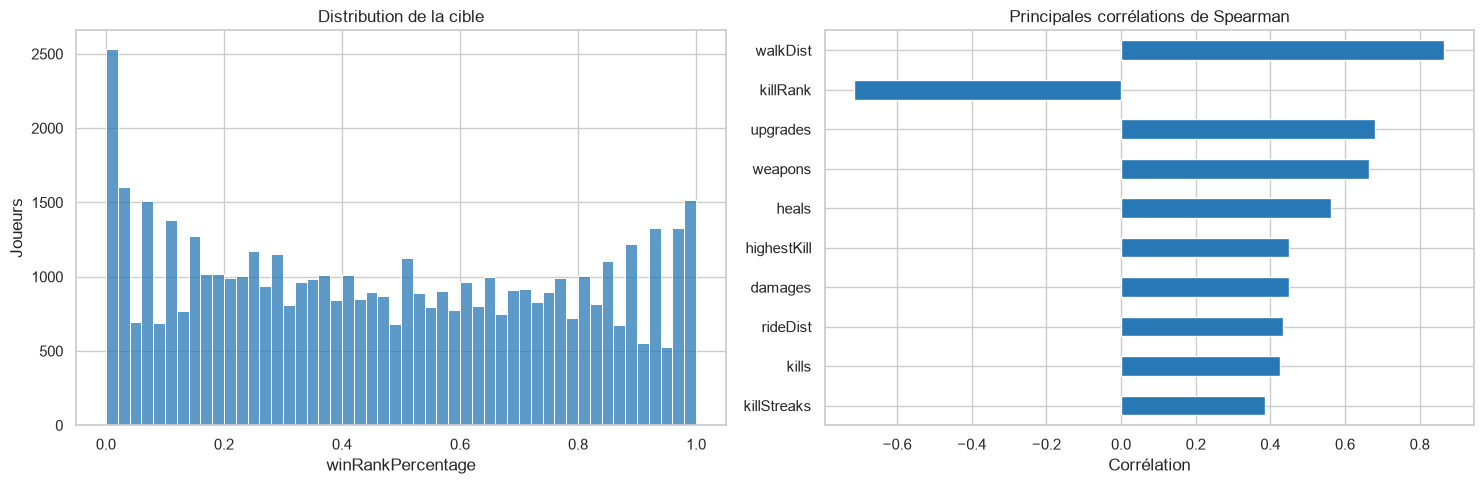

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_target_distribution(train, axes[0])
plot_top_correlations(train, axes[1])
plt.tight_layout()

drift_columns = (
    "walkDist", "rideDist", "damages", "kills",
    "weapons", "upgrades", "heals", "maxRank",
)
display(distribution_shift_summary(train, test, drift_columns).round(4))
display(game_mode_summary(train).round(4))

**Observation et décision.** La mobilité à pied domine le signal brut; équipement, soins et combat apportent des voies complémentaires. Les cibles moyennes restent proches entre solo, duo et squad (0,461 à 0,486); leurs taux de victoire diffèrent surtout avec la taille moyenne de la grille (`maxRank`), donc le mode est gardé comme contexte et non comme effet causal. `killRank` est très informatif mais proche du mécanisme final : il sera isolé dans un scénario post-match et accompagné d'une ablation. Les écarts train/test sont faibles, donc aucune correction de domaine n'est ajoutée.

## 4. Feature Engineering

**Question.** Quelles transformations résument les constats sans créer un catalogue de ratios ?

**Méthode.** Un contrat déterministe conserve huit variables brutes fortes et ajoute sept représentations lisibles. `killRank` est la seule différence entre le contrat comportemental et le contrat post-match.

In [5]:
X_train, X_test = build_train_test_features(
    train, test, include_kill_rank=True
)
X_behavior, _ = build_train_test_features(
    train, test, include_kill_rank=False
)

rationale = pd.DataFrame.from_dict(
    FEATURE_RATIONALE, orient="index", columns=["formule", "justification"]
)
display(rationale)
print(f"Contrat post-match: {X_train.shape[1]} features")
print(f"Contrat comportemental: {X_behavior.shape[1]} features")
assert list(X_train.columns) == list(X_test.columns)
assert np.isfinite(X_train.to_numpy()).all()
assert TARGET not in X_train

,formule,justification
walk_distance_per_match_minute,walkDist / (gameTime / 60),Normalise la mobilité par la durée globale du ...
damage_per_kill,"damages / kills si kills > 0, sinon 0",Distingue dégâts et conversion en éliminations...
combat_activity,kills + assists + knocks,Résume le volume d'engagement offensif.
resource_activity,weapons + upgrades + heals,Résume collecte et progression sans faux rythm...
mode_solo / mode_duo / mode_squad,famille extraite de gameType,Encode le contexte principal; les modes spécia...


Contrat post-match: 16 features
Contrat comportemental: 15 features


**Décision.** Les faux rythmes individuels sont évités : `walk_distance_per_match_minute` nomme explicitement son dénominateur. `resource_activity` remplace le précédent loot par minute. Les IDs, la date, les scores externes, `highestKill`, les agrégats de groupe et la cible sont exclus.

## 5. Validation Strategy

**Question.** Comment empêcher qu'un modèle voie une partie pendant l'entraînement puis soit évalué sur un autre joueur de cette même partie ?

**Méthode.** Comparaison du chevauchement d'un split aléatoire et d'un split groupé, puis création d'un `GroupKFold(gameId)` à cinq folds. Les identifiants corrompus sont isolés ligne par ligne pour éviter de fusionner artificiellement des matchs.

In [6]:
display(split_leakage_comparison(train).round(3))
folds = make_group_folds(train)
fold_audit = audit_group_folds(train, folds)
display(fold_audit)
assert fold_audit["shared_groups"].eq(0).all()

,train_rows,validation_rows,shared_games,validation_rows_from_seen_games_pct
strategy,,,,
Random row split,40000,10000,5100,56.5
Grouped gameId split,39875,10125,0,0.0


,fold,train_rows,validation_rows,shared_groups
0,1,40000,10000,0
1,2,40000,10000,0
2,3,40000,10000,0
3,4,40000,10000,0
4,5,40000,10000,0


**Décision.** La validation croisée groupée est l'unique stratégie principale. Un split aléatoire est rejeté pour fuite de match. Un split temporel n'est pas retenu car la pseudo-date n'est pas un timestamp de partie; le fichier test reste néanmoins externe et n'est jamais utilisé pour choisir le modèle.

## 6. Modeling

**Question.** Quelle famille modélise le mieux les non-linéarités avec un protocole identique ?

**Méthode.** Une médiane de référence puis Random Forest, XGBoost, LightGBM et CatBoost. Chaque modèle reçoit les mêmes 16 features et les mêmes cinq folds. Le tableau unique rapporte MAE, RMSE, R², temps, taille du contrat et écart train/validation.

,rank,model,mae,mae_std,rmse,r2,train_mae,fit_seconds,predict_seconds,feature_count,overfitting
0,1,XGBoost,0.06156,0.00083,0.08666,0.92053,0.05263,5.17966,0.09810,16,écart modéré
1,2,LightGBM,0.06173,0.00087,0.08671,0.92043,0.05532,11.78233,0.35004,16,écart modéré
2,3,CatBoost,0.06177,0.00087,0.08667,0.92051,0.05886,9.46953,0.02504,16,faible écart
3,4,Random Forest,0.06555,0.00086,0.09263,0.90920,0.03034,26.72713,1.22075,16,écart élevé
4,5,Median baseline,0.26799,0.00149,0.30781,-0.00244,0.26798,0.00000,0.00000,16,non applicable


**Observation.** `XGBoost` obtient la meilleure MAE groupée: **0.06156**.

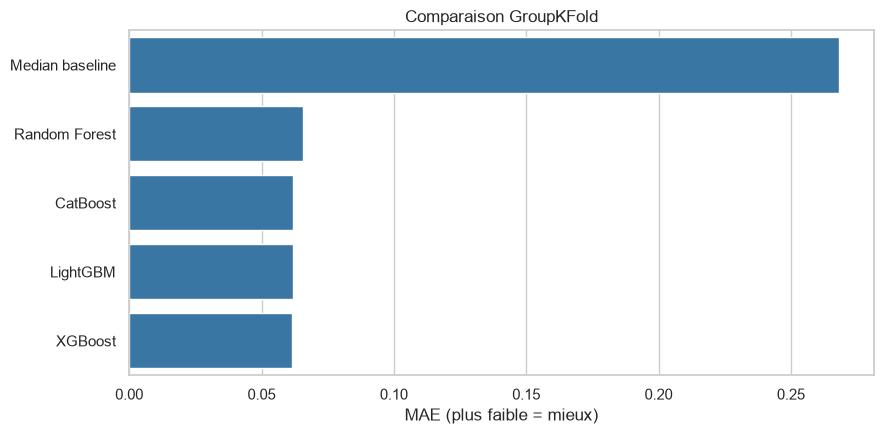

In [7]:
benchmark, oof_predictions, fold_details = compare_models(
    X_train, train[TARGET], folds
)
display(benchmark.round(5))
plot_model_comparison(benchmark)
plt.tight_layout()

winner = benchmark.loc[
    benchmark["model"].ne("Median baseline"), "model"
].iloc[0]
winner_oof = oof_predictions[winner]
display(
    Markdown(
        f"**Observation.** `{winner}` obtient la meilleure MAE groupée: "
        f"**{benchmark.loc[benchmark['model'].eq(winner), 'mae'].iloc[0]:.5f}**."
    )
)

## 7. Evaluation et ablation

Le modèle gagnant est maintenant réévalué sans `killRank`. La projection sur la grille légale de `maxRank` est mesurée séparément : elle n'est conservée que si elle réduit la MAE.

,mae,rmse,r2,features
scenario,,,,
post_match_with_killRank,0.06156,0.08667,0.92053,16
behavior_without_killRank,0.09335,0.13044,0.81996,15
post_match_grid_snapped,0.06111,0.08743,0.91913,16


,rows,mae
match_size,,
very_small,20,0.33565
small,422,0.17846
medium,41778,0.06343
large,7780,0.04448


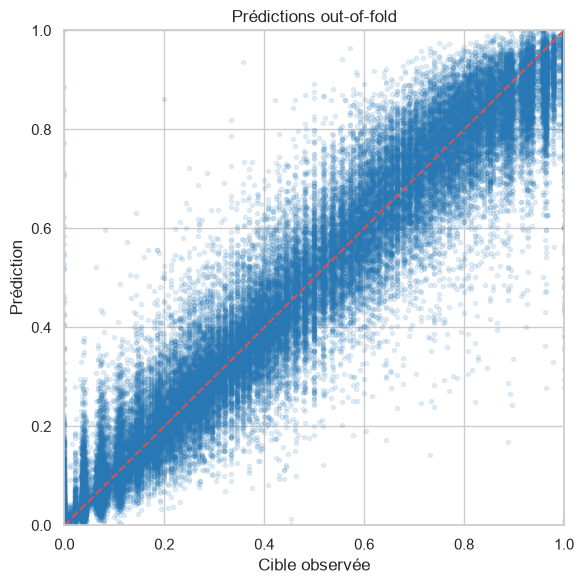

In [8]:
winner_estimator = build_model_candidates()[winner]
behavior_summary, behavior_oof, _ = cross_validate_model(
    winner, winner_estimator, X_behavior, train[TARGET], folds
)
raw_metrics = regression_metrics(train[TARGET], winner_oof)
snapped_oof = snap_to_rank_grid(winner_oof, train["maxRank"])
snapped_metrics = regression_metrics(train[TARGET], snapped_oof)

ablation = pd.DataFrame(
    [
        {"scenario": "post_match_with_killRank", **raw_metrics, "features": X_train.shape[1]},
        {"scenario": "behavior_without_killRank", **{k: behavior_summary[k] for k in ("mae", "rmse", "r2")}, "features": X_behavior.shape[1]},
        {"scenario": "post_match_grid_snapped", **snapped_metrics, "features": X_train.shape[1]},
    ]
).set_index("scenario")
display(ablation.round(5))
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
ablation.to_csv(ARTIFACT_DIR / "killrank_ablation.csv")
display(error_by_match_size(train, winner_oof).round(5))

fig, axis = plt.subplots(figsize=(6, 6))
plot_predictions(train[TARGET], pd.Series(winner_oof), axis)
plt.tight_layout()

In [9]:
killrank_cost = behavior_summary["mae"] - raw_metrics["mae"]
grid_gain = raw_metrics["mae"] - snapped_metrics["mae"]
display(
    Markdown(
        f"**Interprétation.** Sans `killRank`, la MAE augmente de "
        f"**{killrank_cost:.5f}** : le score post-match dépend fortement de ce rang final. "
        f"La projection sur la grille réduit la MAE de **{grid_gain:.5f}**. "
        "Les très petites parties restent les plus difficiles et peu représentées."
    )
)

**Interprétation.** Sans `killRank`, la MAE augmente de **0.03178** : le score post-match dépend fortement de ce rang final. La projection sur la grille réduit la MAE de **0.00045**. Les très petites parties restent les plus difficiles et peu représentées.

## 8. Modèle final et soumission

La famille gagnante est ajustée une seule fois sur les 50 000 lignes, puis publiée avec la liste ordonnée des features, le benchmark et les hashes bruts. Le test est transformé par la même fonction et les prédictions sont projetées sur leur grille légale.

In [10]:
final_model = fit_final_model(winner, X_train, train[TARGET])
artifact_paths = save_model_bundle(
    final_model, X_train.columns, benchmark
)

submission = build_submission(test, final_model.predict(X_test))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
submission_path = OUTPUT_DIR / "submission.csv"
submission.to_csv(submission_path, index=False)

assert len(submission) == len(test)
assert submission[TARGET].between(0, 1).all()
assert submission[TARGET].notna().all()
display(submission.head())
print({**artifact_paths, "submission": submission_path})

,playerId,teamId,gameId,winRankPercentage
0,fdb7d0af46a788,897c68f1df2b33,35ab88ab7516ad,0.833333
1,cfa5a4ed838e8f,e7d1e2c433debe,e05f33046a739f,0.750000
2,cbec92e083ebcd,52ff12219a050c,ba14752a861c4d,0.896552
3,94514c935686ac,6718223e4d7dfa,42c9e8ca738110,0.829787
4,a05a6b38045f65,372d871d4e82b7,e196ff3b6f8ced,0.565217


{'model': PosixPath('/Users/surelmanda/GameLoft/Game-Player-Analysis/artifacts/model.joblib'), 'benchmark': PosixPath('/Users/surelmanda/GameLoft/Game-Player-Analysis/artifacts/model_comparison.csv'), 'manifest': PosixPath('/Users/surelmanda/GameLoft/Game-Player-Analysis/artifacts/model_manifest.json'), 'submission': PosixPath('/Users/surelmanda/GameLoft/Game-Player-Analysis/data/output/submission.csv')}


## 9. Conclusion

- Le vrai risque méthodologique est la fuite par partie, neutralisée par `GroupKFold(gameId)`.
- La date est une pseudo-date d'export et les rosters visibles sont incomplets; ni validation calendaire ni agrégats lobby ne sont défendables.
- Mobilité, collecte et combat décrivent plusieurs chemins vers un bon rang.
- `killRank` est valide pour ce problème explicitement post-partie, mais son ablation montre qu'il ne faut pas présenter ce modèle comme early-game.
- Le modèle final reste volontairement simple : un contrat numérique déterministe, quatre familles comparées, aucun tuning ou calibrage dont le gain ne justifie pas la complexité.

**Limites.** Pas de cible test, pas de trajectoire joueur, pas de roster complet, pas de causalité et pas de vrai timestamp. Une version early-game nécessiterait des snapshots temporels, une identité joueur stable et un holdout réellement futur.